In [9]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

In [10]:
data=pd.read_csv("LRC.data",sep=(','))
data.sample()

,T,2,8,3,5,1,8.1,13,0,6,6.1,10,8.2,0.1,8.3,0.2,8.4
7707,E,2,3,2,1,2,7,7,5,6,7,6,8,2,8,5,10


In [11]:
x=data.iloc[:,1:17]
y=data.select_dtypes(include=[object])
x,y

(       2   8  3  5  1  8.1  13  0  6  6.1  10  8.2  0.1  8.3  0.2  8.4
 0      5  12  3  7  2   10   5  5  4   13   3    9    2    8    4   10
 1      4  11  6  8  6   10   6  2  6   10   3    7    3    7    3    9
 2      7  11  6  6  3    5   9  4  6    4   4   10    6   10    2    8
 3      2   1  3  1  1    8   6  6  6    6   5    9    1    7    5   10
 4      4  11  5  8  3    8   8  6  9    5   6    6    0    8    9    7
 ...   ..  .. .. .. ..  ...  .. .. ..  ...  ..  ...  ...  ...  ...  ...
 19994  2   2  3  3  2    7   7  7  6    6   6    4    2    8    3    7
 19995  7  10  8  8  4    4   8  6  9   12   9   13    2    9    3    7
 19996  6   9  6  7  5    6  11  3  7   11   9    5    2   12    2    4
 19997  2   3  4  2  1    8   7  2  6   10   6    8    1    9    5    8
 19998  4   9  6  6  2    9   5  3  1    8   1    8    2    7    2    8
 
 [19999 rows x 16 columns],
        T
 0      I
 1      D
 2      N
 3      G
 4      S
 ...   ..
 19994  D
 19995  C
 19996  T
 19997

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

In [14]:
ss=StandardScaler()
ss.fit(x_train)
x_train=ss.transform(x_train)
x_test=ss.transform(x_test)
x_train,x_test

/home/sarvatra.in/abhishek.kumar1/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


(array([[ 1.03480207, -0.01107336,  1.92819308, ..., -1.51165914,
          0.11893263,  0.12303048],
        [-1.05821921, -1.82812658, -1.04986054, ...,  0.43200674,
          1.28797002,  0.12303048],
        [ 1.03480207,  0.89745325,  0.93550854, ...,  0.43200674,
         -0.66042562, -1.10989441],
        ...,
        [-0.53496389, -1.22244217, -0.55351827, ...,  1.727784  ,
         -1.05010475, -0.49343197],
        [ 1.03480207,  0.89745325,  1.92819308, ...,  0.43200674,
          1.28797002,  1.97241781],
        [ 0.51154675,  1.20029545, -0.55351827, ...,  0.43200674,
          0.50861176,  0.73949292]], shape=(15999, 16)),
 array([[5.00000000e+00, 8.00000000e+00, 7.00000000e+00, ...,
         8.00000000e+00, 4.00000000e+00, 8.00000000e+00],
        [7.00000000e+00, 1.30000000e+01, 6.00000000e+00, ...,
         1.10000000e+01, 4.00000000e+00, 8.00000000e+00],
        [4.00000000e+00, 1.10000000e+01, 5.00000000e+00, ...,
         8.00000000e+00, 7.19469487e-17, 8.00000000e

In [15]:
mlp=MLPClassifier(hidden_layer_sizes=(250,300),max_iter=100,activation="logistic")

In [16]:
!pip install yellowbrick

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.6/282.6 KB 2.5 MB/s eta 0:00:000:00:01m eta 0:00:01


/home/sarvatra.in/abhishek.kumar1/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


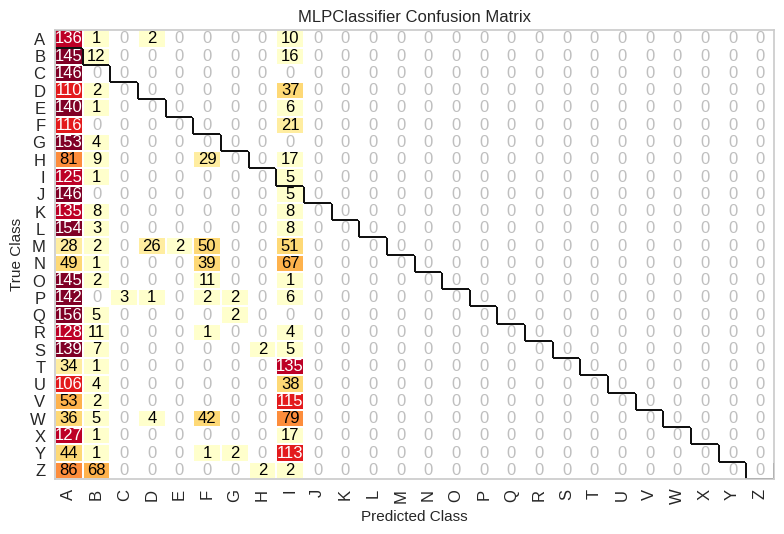

In [18]:
from yellowbrick.classifier import confusion_matrix
cm = confusion_matrix(mlp,x_train,y_train.values.ravel(),
                      x_test,y_test.values.ravel(),
                      classes=list("ABCDEFGHIJKLMNOPQRSTUVWXYZ"))
                      

In [19]:
cm.fit(x_train,y_train.values.ravel())
y_pred=cm.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.07475
